# ARMADO DE SET DE DATOS DE TEST

GEENRACION DE TEST PARA VALIDAR CON MODELOS 2026

In [ ]:
import os, re, glob, random, shutil

TILES_DIR = r"D:\Silos\Base_2026\procesado_sin_nubes\tiles"
POLY_DIR  = r"D:\Silos\Base_2026\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
TEST_DIR  = r"D:\Silos\Base_2026\test"
N_TOTAL, SEED = 5, 456
os.makedirs(TEST_DIR, exist_ok=True)

tifs = [os.path.basename(f) for f in glob.glob(os.path.join(TILES_DIR, "*.tif"))]
def month_of(name):
    m = re.search(r'2026[_\-](\d{1,2})[_\-]', name)
    return int(m.group(1)) if m else None

by_month = {}
for t in tifs: by_month.setdefault(month_of(t), []).append(t)
print("Teselas 2026 por mes:")
for m in sorted(by_month, key=lambda x:(x is None, x)):
    print(f"  mes {m}: {len(by_month[m])}")

months = sorted(m for m in by_month if m is not None)
rng = random.Random(SEED)
base, extra = N_TOTAL // len(months), N_TOTAL - (N_TOTAL//len(months))*len(months)
per = {m: base + (1 if i < extra else 0) for i, m in enumerate(months)}

selected = []
for m in months:
    pool = sorted(by_month[m]); rng.shuffle(pool)
    selected += pool[:min(per[m], len(pool))]

def copy_shp(stem, src, dst):
    n = 0
    for ext in (".shp",".shx",".dbf",".prj",".cpg"):
        p = os.path.join(src, stem+ext)
        if os.path.exists(p): shutil.copy2(p, dst); n += 1
    return n

print(f"\nSeleccionadas {len(selected)} (semilla {SEED}):")
for t in selected:
    stem = os.path.splitext(t)[0]
    shutil.copy2(os.path.join(TILES_DIR, t), TEST_DIR)
    ncand = copy_shp(stem + "_PERCENTILE_POLYGONS", POLY_DIR, TEST_DIR)
    print(f"  {t}  ->  {'con candidatos' if ncand else 'SIN candidatos (digitalizar a mano si hay bolsas)'}")
print(f"\nCopiado a: {TEST_DIR}. Ahora curá los *_PERCENTILE_POLYGONS.shp en QGIS.")

Teselas 2026 por mes:
  mes 6: 796
  mes 7: 380

Seleccionadas 15 (semilla 456):
  2026_6_19_0_tile_r07_c10.tif  ->  con candidatos
  2026_6_11_0_tile_r14_c05.tif  ->  con candidatos
  2026_6_22_0_tile_r13_c04.tif  ->  con candidatos
  2026_6_27_0_tile_r02_c04.tif  ->  con candidatos
  2026_6_19_0_tile_r09_c01.tif  ->  con candidatos
  2026_6_29_0_tile_r16_c02.tif  ->  con candidatos
  2026_6_19_0_tile_r03_c09.tif  ->  con candidatos
  2026_6_14_1_tile_r09_c01.tif  ->  con candidatos
  2026_7_2_0_tile_r13_c04.tif  ->  con candidatos
  2026_7_9_0_tile_r13_c03.tif  ->  con candidatos
  2026_7_2_0_tile_r17_c01.tif  ->  con candidatos
  2026_7_17_0_tile_r08_c05.tif  ->  con candidatos
  2026_7_2_0_tile_r09_c02.tif  ->  con candidatos
  2026_7_24_1_tile_r12_c03.tif  ->  con candidatos
  2026_7_24_0_tile_r10_c04.tif  ->  con candidatos

Copiado a: D:\Silos\Base_2026\test. Ahora curá los *_PERCENTILE_POLYGONS.shp en QGIS.


In [ ]:
# Correr cuando tengas agostro

import os, re, glob, random, shutil

TILES_DIR = r"D:\Silos\Base_2026\procesado_sin_nubes\tiles"
POLY_DIR  = r"D:\Silos\Base_2026\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
TEST_DIR  = r"D:\Silos\Base_2026\test"
MES, N_AGOSTO, SEED = 8, 5, 456          # <-- agosto, 5 teselas
os.makedirs(TEST_DIR, exist_ok=True)

def month_of(name):
    m = re.search(r'2026[_\-](\d{1,2})[_\-]', name); return int(m.group(1)) if m else None

# ya presentes en test (para no repetir)
ya = {f for f in os.listdir(TEST_DIR) if f.endswith(".tif")}
# candidatas: solo agosto y que NO estén ya en test
pool = sorted(os.path.basename(f) for f in glob.glob(os.path.join(TILES_DIR, "*.tif"))
              if month_of(os.path.basename(f)) == MES and os.path.basename(f) not in ya)

print(f"Teselas de agosto disponibles (no curadas aún): {len(pool)}")
rng = random.Random(SEED + MES)          # semilla distinta para agosto, reproducible
rng.shuffle(pool)
selected = pool[:min(N_AGOSTO, len(pool))]

def copy_shp(stem, src, dst):
    n = 0
    for ext in (".shp",".shx",".dbf",".prj",".cpg"):
        p = os.path.join(src, stem+ext)
        if os.path.exists(p): shutil.copy2(p, dst); n += 1
    return n

print(f"\nAgregando {len(selected)} de agosto:")
for t in selected:
    stem = os.path.splitext(t)[0]
    shutil.copy2(os.path.join(TILES_DIR, t), TEST_DIR)
    ncand = copy_shp(stem + "_PERCENTILE_POLYGONS", POLY_DIR, TEST_DIR)
    print(f"  {t}  ->  {'con candidatos' if ncand else 'SIN candidatos (digitalizar a mano si hay bolsas)'}")
print(f"\nListo. Test ahora tiene {len(ya)+len(selected)} teselas. Curá las nuevas en QGIS.")

# Pipeline 2026 — TODO EN UNO (descarga → composite → merge → clip → tile → INBNV)

Genera tiles nuevos de **2026** y su GT semiautomático (polígonos INBNV), replicando
exactamente tu pipeline 01-06, pero guardando **todo bajo una carpeta nueva** (`BASE_2026`)
para no mezclar con lo ya hecho.

**Flujo:** corré las celdas en orden. Cada etapa lee de la carpeta de la etapa anterior.
La nomenclatura de tiles queda idéntica: `2026_<mes>_<dia>_<seq>_tile_rNN_cNN.tif`.

**Lo único que tocás es la celda de CONFIG** (fechas, tiles MGRS, carpeta raíz).

## 0. Configuración (editá solo esto)

In [ ]:
import os
import re
import glob
from pathlib import Path
from datetime import date, datetime
from collections import defaultdict
import numpy as np
import rasterio
from tqdm import tqdm

# ===================== CONFIG 2026 (LO ÚNICO QUE TOCÁS) =====================
# Carpeta raíz NUEVA: todo lo de 2026 vive acá, separado de lo anterior
BASE_2026 = Path(r"D:\Silos\Base_2026")

# --- Descarga (AWS S3 Sentinel-2 L2A) ---
# Tiles MGRS que cubren tu zona (Marcos Juárez). Confirmá que sean los mismos
# que usaste para 2020-2025. Si tu zona cae en un solo tile, dejá uno solo.
MGRS_TILES = ["20HNH", "20HNJ", "20HNK"]
START_DATE = date(2026, 6, 1)
END_DATE   = date(2026, 7, 30)   # OJO: hoy julio/agosto 2026 todavía no existen

# --- Clip a zona agrícola (mismo shapefile que siempre) ---
SHAPEFILE_AGRI = r"C:\Users\m\Documents\Tesis_Silos\Silos_FR_MCDtf\GeoDatos\argentina_Agriculture_MERGE_Marcos_Juarez.shp"

# --- Tiling (idéntico a tu 05) ---
TILE_SIZE = 1024
OVERLAP_PERCENT = 20

# --- INBNV / GT (idéntico a tu 06) ---
BANDA_ROJA = 1      # B04
BANDA_VERDE = 2     # B03
BANDA_NIR = 4       # B08
PERCENTILE = 99.8
MIN_PIXELS = 3
BUFFER_PIXELS = 1
# ===========================================================================

# Subcarpetas derivadas (NO tocar) — replican tu estructura, pero bajo BASE_2026
DL_DIR        = BASE_2026 / "s2_aws_downloads_structured"
COMPOSITE_DIR = BASE_2026 / "procesado_sin_nubes"
MOSAIC_DIR    = COMPOSITE_DIR / "mosaics"
CLIP_DIR      = MOSAIC_DIR / "mosaics_clipped"
TILES_DIR     = COMPOSITE_DIR / "tiles"
INDEX_DIR     = TILES_DIR / "indices_INBNV"
MASK_DIR      = INDEX_DIR / "masks"
POLY_DIR      = MASK_DIR / "polygons"

for d in [BASE_2026, DL_DIR, COMPOSITE_DIR, MOSAIC_DIR, CLIP_DIR, TILES_DIR, INDEX_DIR, MASK_DIR, POLY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta raíz 2026:", BASE_2026)
print("Rango de fechas:", START_DATE, "->", END_DATE)
print("Tiles MGRS:", MGRS_TILES)
print("Estructura creada. Tiles finales irán a:", TILES_DIR)


Carpeta raíz 2026: D:\Silos\Base_2026
Rango de fechas: 2026-06-01 -> 2026-07-30
Tiles MGRS: ['20HNH', '20HNJ']
Estructura creada. Tiles finales irán a: D:\Silos\Base_2026\procesado_sin_nubes\tiles


## 1. Descarga (AWS S3)
Baja las bandas Sentinel-2 L2A para los tiles MGRS y el rango de fechas, manteniendo la
estructura de carpetas que espera la etapa de composite.

In [2]:
# ============ ETAPA 1/6: DESCARGA (AWS S3) — SOLO bandas necesarias ============
# Requiere: pip install boto3
import warnings, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", message="Unverified HTTPS request")

import boto3
from botocore import UNSIGNED
from botocore.config import Config

BUCKET = "sentinel-s2-l2a"
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

# Lo único que necesita el composite (tu etapa 2): 4 bandas en R10m + SCL en R20m
NEEDED_SUFFIXES = (
    "/R10m/B02.jp2", "/R10m/B03.jp2", "/R10m/B04.jp2", "/R10m/B08.jp2",
    "/R20m/SCL.jp2",
)

def tile_to_prefix(tile_code):
    return f"tiles/{tile_code[:2]}/{tile_code[2]}/{tile_code[3:]}/"

total_descargados = 0
for tile in MGRS_TILES:
    prefix = tile_to_prefix(tile)
    print(f"\nTile {tile} -> {prefix}")
    paginator = s3.get_paginator("list_objects_v2")
    pages = paginator.paginate(Bucket=BUCKET, Prefix=prefix, RequestPayer="requester")

    keys = []
    for page in pages:
        for obj in page.get("Contents", []):
            key = obj["Key"]
            parts = key.split("/")  # tiles/20/H/NH/YYYY/M/D/SEQ/...
            try:
                yyyy = int(parts[4]); mm = int(parts[5]); dd = int(parts[6])
                dt = datetime(yyyy, mm, dd).date()
            except Exception:
                continue
            if not (START_DATE <= dt <= END_DATE):
                continue
            if key.endswith(NEEDED_SUFFIXES):   # <-- solo los 5 archivos útiles
                keys.append(key)

    print(f"  Archivos necesarios (5 por escena): {len(keys)}")
    for key in tqdm(keys, desc=f"Descargando {tile}"):
        local_path = DL_DIR / key
        local_path.parent.mkdir(parents=True, exist_ok=True)
        if local_path.exists():
            continue
        try:
            s3.download_file(BUCKET, key, str(local_path), ExtraArgs={"RequestPayer": "requester"})
            total_descargados += 1
        except Exception as e:
            print(f"  Error descargando {key}: {e}")

print(f"\nDescarga finalizada. Archivos nuevos: {total_descargados}")
print(f"~{total_descargados // 5} escenas (5 archivos c/u). Guardado en: {DL_DIR}")


Tile 20HNH -> tiles/20/H/NH/
  Archivos necesarios (5 por escena): 140


Descargando 20HNH: 100%|██████████| 140/140 [13:13<00:00,  5.67s/it]



Tile 20HNJ -> tiles/20/H/NJ/
  Archivos necesarios (5 por escena): 135


Descargando 20HNJ: 100%|██████████| 135/135 [13:48<00:00,  6.14s/it]


Descarga finalizada. Archivos nuevos: 175
~35 escenas (5 archivos c/u). Guardado en: D:\Silos\Base_2026\s2_aws_downloads_structured


## 2. Composite 4 bandas sin nubes (R,G,B,NIR con máscara SCL)

In [3]:
# ============ ETAPA 2/6: COMPOSITE 4 BANDAS SIN NUBES (tu 02) ============
from rasterio.enums import Resampling
from rasterio import warp

def procesar_imagenes_sentinel(ruta_base, ruta_salida):
    os.makedirs(ruta_salida, exist_ok=True)
    print(f"Composite -> {ruta_salida}")

    valores_scl_validos = [4, 5, 6, 7, 11]
    bandas_10m_a_usar = ['B04', 'B03', 'B02', 'B08']   # orden de salida: R, G, B, NIR

    n_ok = 0
    for root, dirs, files in os.walk(ruta_base):
        if root.endswith("R10m"):
            ruta_scl_20m = root.replace("R10m", "R20m")
            archivo_scl = os.path.join(ruta_scl_20m, "SCL.jp2")
            rutas_bandas = {b: os.path.join(root, f"{b}.jp2") for b in bandas_10m_a_usar}

            if not os.path.exists(archivo_scl):
                continue
            if not all(os.path.exists(p) for p in rutas_bandas.values()):
                continue

            try:
                with rasterio.open(archivo_scl) as src_scl:
                    scl_data = src_scl.read(1)
                    perfil_scl = src_scl.profile
                    mascara_20m = np.isin(scl_data, valores_scl_validos)

                with rasterio.open(rutas_bandas['B04']) as src_10m_sample:
                    perfil_10m = src_10m_sample.profile
                    forma_destino = src_10m_sample.shape

                mascara_10m = np.empty(forma_destino, dtype=np.uint8)
                warp.reproject(
                    source=mascara_20m.astype(np.uint8),
                    destination=mascara_10m,
                    src_transform=perfil_scl['transform'], src_crs=perfil_scl['crs'],
                    dst_transform=perfil_10m['transform'], dst_crs=perfil_10m['crs'],
                    resampling=Resampling.nearest
                )
                mascara_10m_bool = mascara_10m.astype(bool)

                stack_10m = []
                for banda in bandas_10m_a_usar:
                    with rasterio.open(rutas_bandas[banda]) as src_banda:
                        stack_10m.append(src_banda.read(1))
                array_stack = np.array(stack_10m, dtype=perfil_10m['dtype'])

                valor_nodata = 0
                array_stack[:, ~mascara_10m_bool] = valor_nodata

                partes_ruta = root.replace(str(ruta_base), '').strip(os.sep).split(os.sep)
                nombre_archivo = f"{'_'.join(partes_ruta)}.tif"
                ruta_archivo_salida = os.path.join(ruta_salida, nombre_archivo)

                perfil_salida = perfil_10m.copy()
                perfil_salida.update({'driver': 'GTiff', 'count': len(bandas_10m_a_usar),
                                      'nodata': valor_nodata, 'compress': 'lzw'})

                with rasterio.open(ruta_archivo_salida, 'w', **perfil_salida) as dst:
                    dst.write(array_stack)
                n_ok += 1
            except Exception as e:
                print(f"  ERROR en {root}: {e}")

    print(f"Composites generados: {n_ok}")

procesar_imagenes_sentinel(str(DL_DIR / "tiles"), str(COMPOSITE_DIR))
print("--- Etapa 2 lista ---")


Composite -> D:\Silos\Base_2026\procesado_sin_nubes
Composites generados: 55
--- Etapa 2 lista ---


## 3. Merge de escenas por fecha

In [4]:
# ============ ETAPA 3/6: MERGE DE ESCENAS POR FECHA (tu 03) ============
from rasterio.merge import merge as rio_merge

EXTS = (".tif", ".tiff", ".jp2", ".TIF", ".JP2")
pattern = re.compile(r".*?(\d{4}_\d{1,2}_\d{1,2}_\d+).*")

groups = defaultdict(list)
for p in COMPOSITE_DIR.iterdir():
    if p.is_file() and p.suffix in EXTS:
        m = pattern.search(p.name)
        if m:
            groups[m.group(1)].append(p)

print(f"Grupos (escenas) detectados: {len(groups)}")

def mosaic_and_save(file_list, out_path):
    srcs = []
    try:
        for fp in file_list:
            srcs.append(rasterio.open(fp))
        mosaic_arr, out_trans = rio_merge(srcs)
        out_meta = srcs[0].meta.copy()
        out_meta.update({"driver": "GTiff", "height": mosaic_arr.shape[1],
                         "width": mosaic_arr.shape[2], "transform": out_trans,
                         "count": mosaic_arr.shape[0]})
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(mosaic_arr)
        print(f"  OK mosaico: {out_path.name} ({mosaic_arr.shape[0]}b, {mosaic_arr.shape[1]}x{mosaic_arr.shape[2]})")
    except Exception as e:
        print(f"  ERROR mosaicing {file_list}: {e}")
    finally:
        for s in srcs:
            try: s.close()
            except: pass

for key, files in groups.items():
    files = sorted(files)
    out_fp = MOSAIC_DIR / f"{key}_mosaic.tif"
    if out_fp.exists():
        continue
    mosaic_and_save(files, out_fp)

print("--- Etapa 3 lista ---")


Grupos (escenas) detectados: 28
  OK mosaico: 2026_6_22_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_6_24_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_6_27_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_6_29_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_12_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_14_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_17_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_19_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_1_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_22_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_24_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_24_1_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_2_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_4_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_4_1_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_7_0_mosaic.tif (4b, 20976x10980)
  OK mosaico: 2026_7_7_1_mosaic.tif (4b, 10980x10980)
  OK mosaico: 2026_7_9_0_mosaic.tif (4b

## 4. Clip a la zona agrícola (shapefile Marcos Juárez)

In [5]:
# ============ ETAPA 4/6: CLIP A ZONA AGRÍCOLA (tu 04) ============
import geopandas as gpd
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping, box

NODATA = np.nan
COMPRESS = "LZW"

gdf_agri = gpd.read_file(SHAPEFILE_AGRI)
if gdf_agri.empty:
    raise SystemExit(f"Shapefile {SHAPEFILE_AGRI} vacío.")
gdf_agri['geometry'] = gdf_agri['geometry'].buffer(0)

def geometries_intersecting_raster(raster_path, gdf_shp):
    with rasterio.open(raster_path) as src:
        rast_crs = src.crs
        bounds = src.bounds
        src_dtype = src.dtypes[0]
    if gdf_shp.crs != rast_crs:
        try:
            gdf_rast = gdf_shp.to_crs(rast_crs)
        except Exception:
            return [], src_dtype
    else:
        gdf_rast = gdf_shp
    bbox_geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
    try:
        sindex = gdf_rast.sindex
        possible_idx = list(sindex.intersection(bbox_geom.bounds))
        possible = gdf_rast.iloc[possible_idx] if possible_idx else gdf_rast.iloc[[]]
    except Exception:
        possible = gdf_rast
    if len(possible) == 0:
        return [], src_dtype
    intersects = possible[possible.geometry.intersects(bbox_geom)]
    if intersects.empty:
        return [], src_dtype
    return list(intersects.geometry.values), src_dtype

rasters = sorted(glob.glob(str(MOSAIC_DIR / "*.tif")))
print(f"Mosaics a recortar: {len(rasters)}")

for rast_path in tqdm(rasters, desc="Clip"):
    fname = os.path.splitext(os.path.basename(rast_path))[0]
    out_path = CLIP_DIR / f"{fname}_clipped.tif"
    if out_path.exists():
        continue

    geoms, src_dtype = geometries_intersecting_raster(rast_path, gdf_agri)
    if len(geoms) == 0:
        continue
    shapes = [mapping(g) for g in geoms]

    with rasterio.open(rast_path) as src:
        meta = src.meta.copy()
        # fill temporal compatible con el dtype origen; luego pasamos a float32 + NaN
        try:
            info = np.iinfo(np.dtype(src_dtype))
            fill_value = int(info.max)
        except Exception:
            fill_value = 0
        try:
            out_image, out_transform = rio_mask(dataset=src, shapes=shapes, invert=False,
                                                crop=True, nodata=fill_value)
        except Exception as e:
            print(f"  ERROR mask {rast_path}: {e}")
            continue

        out_image = out_image.astype(np.float32)
        out_image[out_image == float(fill_value)] = np.nan

        out_meta = meta.copy()
        out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2],
                         "transform": out_transform, "dtype": "float32",
                         "count": out_image.shape[0], "compress": COMPRESS, "nodata": np.nan})
        try:
            with rasterio.open(out_path, "w", **out_meta) as dst:
                dst.write(out_image)
        except Exception as e:
            print(f"  ERROR guardando {out_path}: {e}")

print("--- Etapa 4 lista ---")


Mosaics a recortar: 28


Clip: 100%|██████████| 28/28 [28:35<00:00, 61.26s/it]

--- Etapa 4 lista ---


## 5. Tiling (1024 px, 20% overlap)

In [6]:
# ============ ETAPA 5/6: TILING 1024px / 20% overlap (tu 05) ============
from rasterio.windows import Window
import warnings
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

def calculate_tile_positions(width, height, tile_size, overlap_percent):
    overlap_pixels = int(tile_size * overlap_percent / 100)
    step_size = tile_size - overlap_pixels
    x_positions, y_positions = [], []
    x = 0
    while x < width:
        x_end = min(x + tile_size, width)
        x_positions.append((x, x_end))
        if x_end >= width: break
        x += step_size
    y = 0
    while y < height:
        y_end = min(y + tile_size, height)
        y_positions.append((y, y_end))
        if y_end >= height: break
        y += step_size
    return x_positions, y_positions

def is_tile_valid(tile_data, threshold_percent=80):
    if tile_data is None or tile_data.size == 0:
        return False
    if np.isinf(tile_data).any():
        return False
    if len(tile_data.shape) == 3:
        valid_pixels = ~np.isnan(tile_data).all(axis=0)
        total_pixels = tile_data.shape[1] * tile_data.shape[2]
        valid_count = valid_pixels.sum()
        if valid_count > 0:
            valid_data = tile_data[:, valid_pixels]
            dark_pixels = np.sum(np.all(valid_data < 50, axis=0))
            dark_percentage_of_valid = (dark_pixels / valid_count) * 100 if valid_count > 0 else 100
        else:
            dark_percentage_of_valid = 100
    else:
        valid_pixels = ~np.isnan(tile_data)
        total_pixels = tile_data.size
        valid_count = valid_pixels.sum()
        dark_percentage_of_valid = (np.sum(tile_data[valid_pixels] < 50) / valid_count * 100) if valid_count > 0 else 100
    valid_percentage = (valid_count / total_pixels) * 100
    return valid_percentage >= 20 and dark_percentage_of_valid < threshold_percent

def calculate_tile_transform(original_transform, x_start, y_start):
    x_coord, y_coord = rasterio.transform.xy(original_transform, y_start, x_start, offset='ul')
    return rasterio.transform.from_origin(x_coord, y_coord, original_transform.a, -original_transform.e)

def generate_tiles_from_mosaic(mosaic_path, output_dir, tile_size, overlap_percent):
    filename = os.path.splitext(os.path.basename(mosaic_path))[0]
    base_name = filename.replace('_mosaic_clipped', '')
    creados = 0
    with rasterio.open(mosaic_path) as src:
        width, height, bands = src.width, src.height, src.count
        x_positions, y_positions = calculate_tile_positions(width, height, tile_size, overlap_percent)
        for row_idx, (y_start, y_end) in enumerate(y_positions):
            for col_idx, (x_start, x_end) in enumerate(x_positions):
                if x_start >= width or y_start >= height:
                    continue
                x_end_adj = min(x_end, width); y_end_adj = min(y_end, height)
                window = Window(x_start, y_start, x_end_adj - x_start, y_end_adj - y_start)
                if window.width <= 0 or window.height <= 0:
                    continue
                try:
                    tile_data = src.read(window=window)
                except Exception:
                    continue
                if not is_tile_valid(tile_data):
                    continue
                if tile_data.shape[1] != tile_size or tile_data.shape[2] != tile_size:
                    padded = np.full((bands, tile_size, tile_size), np.nan, dtype=tile_data.dtype)
                    padded[:, :tile_data.shape[1], :tile_data.shape[2]] = tile_data
                    tile_data = padded
                tile_name = f"{base_name}_tile_r{row_idx:02d}_c{col_idx:02d}.tif"
                tile_path = os.path.join(output_dir, tile_name)
                tile_transform = calculate_tile_transform(src.transform, x_start, y_start)
                tile_meta = src.meta.copy()
                tile_meta.update({'height': tile_data.shape[1], 'width': tile_data.shape[2],
                                  'transform': tile_transform})
                try:
                    with rasterio.open(tile_path, 'w', **tile_meta) as dst:
                        dst.write(tile_data)
                        if src.crs:
                            dst.crs = src.crs
                    creados += 1
                except Exception:
                    continue
    return creados

clipped = [f for f in os.listdir(CLIP_DIR) if f.lower().endswith('.tif')]
print(f"Mosaics recortados a tilear: {len(clipped)}")
total = 0
for fn in tqdm(clipped, desc="Tiling"):
    total += generate_tiles_from_mosaic(str(CLIP_DIR / fn), str(TILES_DIR), TILE_SIZE, OVERLAP_PERCENT)
print(f"Tiles creados: {total}")
print("Guardados en:", TILES_DIR)
print("--- Etapa 5 lista ---")


Mosaics recortados a tilear: 28


Tiling:   0%|          | 0/28 [00:00<?, ?it/s]

Tiling: 100%|██████████| 28/28 [1:45:39<00:00, 226.43s/it]

Tiles creados: 1176
Guardados en: D:\Silos\Base_2026\procesado_sin_nubes\tiles
--- Etapa 5 lista ---


## 6. Índice INBNV → máscara percentil → polígonos GT

In [7]:
# ============ ETAPA 6/6: INBNV -> MÁSCARA -> POLÍGONOS GT (tu 06) ============
from skimage.filters import threshold_triangle, threshold_otsu
from rasterio.features import shapes as rio_shapes
from scipy.ndimage import label, binary_dilation
from shapely.geometry import shape

# --- 6a. Índice INBNV ---
raster_files = glob.glob(str(TILES_DIR / "*.tif"))
print(f"6a. Calculando INBNV sobre {len(raster_files)} tiles...")
np.seterr(divide='ignore', invalid='ignore')
for file_path in raster_files:
    try:
        with rasterio.open(file_path) as src:
            green = src.read(BANDA_VERDE).astype(np.float32)
            red   = src.read(BANDA_ROJA).astype(np.float32)
            nir   = src.read(BANDA_NIR).astype(np.float32)
            meta = src.meta.copy()
        numerator = (green + red) - nir
        denominator = (green + red) + nir
        inbnv = np.where(denominator == 0, 0, numerator / denominator)
        meta.update({'dtype': 'float32', 'count': 1, 'nodata': -9999})
        inbnv[~np.isfinite(inbnv)] = meta['nodata']
        name_part = os.path.splitext(os.path.basename(file_path))[0]
        out_path = INDEX_DIR / f"{name_part}_INBNV.tif"
        with rasterio.open(out_path, 'w', **meta) as dst:
            dst.write(inbnv, 1)
    except Exception as e:
        print(f"  ERROR INBNV {os.path.basename(file_path)}: {e}")

# --- 6b. Máscara por percentil ---
indice_files = glob.glob(str(INDEX_DIR / "*_INBNV.tif"))
print(f"6b. Umbralizando {len(indice_files)} índices (percentil {PERCENTILE})...")
for path_al_indice in indice_files:
    try:
        with rasterio.open(path_al_indice) as src:
            inbnv = src.read(1); nodata = src.nodata; meta = src.meta.copy()
        valid_pixels = inbnv[inbnv != nodata]
        if valid_pixels.size == 0:
            continue
        threshold = np.percentile(valid_pixels, PERCENTILE)
        binary_mask = np.where(inbnv > threshold, 1, 0).astype(np.uint8)
        if nodata is not None:
            binary_mask[inbnv == nodata] = 255
        meta.update({'dtype': 'uint8', 'nodata': 255})
        base_name = os.path.basename(path_al_indice).replace("_INBNV.tif", "_PERCENTILE_MASK.tif")
        with rasterio.open(MASK_DIR / base_name, 'w', **meta) as dst:
            dst.write(binary_mask, 1)
    except Exception as e:
        print(f"  ERROR máscara {os.path.basename(path_al_indice)}: {e}")

# --- 6c. Máscara -> polígonos (GT semiautomático) ---
mask_files = glob.glob(str(MASK_DIR / "*_MASK.tif"))
print(f"6c. Vectorizando {len(mask_files)} máscaras a polígonos...")
for mask_path in mask_files:
    try:
        with rasterio.open(mask_path) as src:
            mask_arr = src.read(1); transform = src.transform; crs = src.crs
        binary = (mask_arr == 1).astype(np.uint8)
        labeled, num_features = label(binary)
        cleaned = np.zeros_like(binary)
        for i in range(1, num_features + 1):
            region = (labeled == i)
            if region.sum() > MIN_PIXELS:
                cleaned[region] = 1
        buffered = binary_dilation(cleaned, iterations=BUFFER_PIXELS).astype(np.uint8)
        polygons = [shape(geom) for geom, val in
                    rio_shapes(buffered, mask=buffered.astype(bool), transform=transform) if val == 1]
        if not polygons:
            continue
        gdf = gpd.GeoDataFrame(geometry=polygons, crs=crs)
        out_file = POLY_DIR / os.path.basename(mask_path).replace("_MASK.tif", "_POLYGONS.shp")
        gdf.to_file(out_file)
    except Exception as e:
        print(f"  ERROR polígonos {os.path.basename(mask_path)}: {e}")

print("\n=== PIPELINE 2026 COMPLETO ===")
print("Tiles RGB+NIR:", TILES_DIR)
print("Polígonos GT (a limpiar en QGIS):", POLY_DIR)


6a. Calculando INBNV sobre 1176 tiles...
6b. Umbralizando 1176 índices (percentil 99.8)...
6c. Vectorizando 1176 máscaras a polígonos...

=== PIPELINE 2026 COMPLETO ===
Tiles RGB+NIR: D:\Silos\Base_2026\procesado_sin_nubes\tiles
Polígonos GT (a limpiar en QGIS): D:\Silos\Base_2026\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons


## Próximos pasos / Notas

**Para armar el test set 2026:**
1. En QGIS cargá los tiles de `BASE_2026\procesado_sin_nubes\tiles` + sus polígonos de
   `...\indices_INBNV\masks\polygons` (que son el GT sucio, ~50% FP).
2. Limpiá el GT a mano (mismo workflow de siempre) sobre un puñado de tiles con silos
   (30-40 alcanzan para un test). Guardá los `gt_*.shp` corregidos.
3. Corré `08_mAP_FINAL` apuntando `TEST_DIR` a tu carpeta de test 2026 limpio, y comparás
   los 4 modelos sobre datos de un año que ninguno vio. Esa es la validación definitiva.

**Si la Etapa 1 (descarga) trae 0 escenas:**
- Recordá que hoy es ~junio 2026: **julio y agosto 2026 todavía no existen**. Solo hay
  principios de junio. Ajustá `START_DATE`/`END_DATE`.
- Confirmá que `MGRS_TILES` sean los que cubren tu zona (los mismos que usaste para 2020-2025).
- El bucket `sentinel-s2-l2a` es **requester-pays**: puede requerir credenciales AWS
  configuradas (`aws configure`) y generar costos mínimos. Si no tenés acceso, la alternativa
  es descargar vía **CDSE** (tu notebook 01, método SentinelHub/ODATA) y después correr desde
  la Etapa 2 — pero ojo, el composite espera la estructura de carpetas del método AWS, así que
  si vas por CDSE habría que adaptar el armado de nombres de la Etapa 2.

In [2]:
# ====================================================================
#  VALIDACIÓN TEMPORAL 2026 — Setup
#  (correr después de las celdas de descarga/procesamiento del 2026)
# ====================================================================
import os, torch, torchvision, rasterio
import numpy as np, pandas as pd, geopandas as gpd
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
from torchvision.ops import box_iou, nms as tv_nms
from pathlib import Path

# --- Config ---
TEST_2026_DIR = r"D:\Silos\Base_2026\test"
GT_SUFFIX     = "_PERCENTILE_POLYGONS"   # sufijo de los shapefiles GT corregidos en QGIS
THRESHOLD     = 0.5
IOU_THRESHOLD = 0.15
NMS_IOU       = 0.3                       # deduplicación post-hoc (igual para todos los modelos)
MODELS = {
    'V2': r"D:\Silos\modelo_silos_v2_optimizado.pth",
    'V3': r"D:\Silos\modelo_silos_v3_aug.pth",
    'V4': r"D:\Silos\modelo_silos_v4_10k.pth",
    'V5': r"D:\Silos\modelo_silos_v5_FINAL.pth",
}
device = torch.device('cpu')

def get_model_architecture(num_classes=2):
    anchor_sizes  = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    ag = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None, weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=ag)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try:    img_data = src.read([1, 2, 3])          # R,G,B (descarta NIR)
        except: img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    mx = np.max(img_data)
    if   mx > 255.0: img_data /= 10000.0
    elif mx > 1.0:   img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def predict_dedup(model, img_t):
    """Predice, filtra por THRESHOLD y aplica NMS (dedup) -> (boxes_np, scores_np)."""
    with torch.no_grad():
        pred = model([img_t.to(device)])
    b = pred[0]['boxes'].cpu(); s = pred[0]['scores'].cpu()
    m = s >= THRESHOLD; b, s = b[m], s[m]
    if len(b) > 0:
        keep = tv_nms(b, s, NMS_IOU); b, s = b[keep], s[keep]
    return b.numpy(), s.numpy()

def find_gt_shp(base, test_dir):
    files = os.listdir(test_dir)
    # 1) GT corregido del 2026: <base>_PERCENTILE_POLYGONS.shp
    cand = next((f for f in files if f == f"{base}{GT_SUFFIX}.shp"), None)
    if cand: return os.path.join(test_dir, cand)
    # 2) fallback estilo notebook 08: gt_<base>.shp
    cand = next((f for f in files if f.startswith("gt_" + base) and f.endswith(".shp")), None)
    if cand: return os.path.join(test_dir, cand)
    return None

def get_gt_boxes(img_name, test_dir):
    base = os.path.splitext(img_name)[0]
    img_path = os.path.join(test_dir, img_name)
    shp_path = find_gt_shp(base, test_dir)
    with rasterio.open(img_path) as src:
        transform, height, width, rcrs = src.transform, src.height, src.width, src.crs
    if not shp_path:
        return torch.zeros((0, 4), dtype=torch.float32)
    boxes = []
    try:
        gdf = gpd.read_file(shp_path)
        if gdf.crs is not None and rcrs is not None and gdf.crs != rcrs:
            gdf = gdf.to_crs(rcrs)                       # alinear CRS por las dudas
        for geom in gdf.geometry:
            if geom is None: continue
            if   geom.geom_type == 'Polygon':      polys = [geom]
            elif geom.geom_type == 'MultiPolygon': polys = list(geom.geoms)
            else:                                  polys = []
            for p in polys:
                xs, ys = zip(*p.exterior.coords)
                rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                y_min, y_max = max(0, min(rows)), min(height, max(rows))
                x_min, x_max = max(0, min(cols)), min(width,  max(cols))
                if x_max > x_min + 1 and y_max > y_min + 1:
                    boxes.append([x_min, y_min, x_max, y_max])
    except Exception as e:
        print(f"[WARN] GT {base}: {e}")
    if not boxes:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.as_tensor(boxes, dtype=torch.float32)

# --- Cargar modelos una sola vez (robusto a state_dict o checkpoint) ---
loaded = {}
for name, path in MODELS.items():
    if not os.path.exists(path):
        print(f"[skip] {name}: no existe {path}"); continue
    m = get_model_architecture().to(device)
    sd = torch.load(path, map_location=device)
    if isinstance(sd, dict) and 'model' in sd and 'optimizer' in sd:
        sd = sd['model']                                # extraer pesos si es checkpoint
    m.load_state_dict(sd); m.eval()
    loaded[name] = m

test_imgs_2026 = sorted([f for f in os.listdir(TEST_2026_DIR) if f.endswith('.tif')])
print(f"Modelos cargados: {list(loaded.keys())}")
print(f"Imágenes test 2026 ({len(test_imgs_2026)}): {test_imgs_2026}")

# Sanity check de escala (debe parecerse al rango de las imágenes de entrenamiento)
if test_imgs_2026:
    with rasterio.open(os.path.join(TEST_2026_DIR, test_imgs_2026[0])) as src:
        arr = src.read([1, 2, 3]).astype('float32')
    print(f"Escala [{test_imgs_2026[0]}]: min={np.nanmin(arr):.1f}  "
          f"max={np.nanmax(arr):.1f}  mean={np.nanmean(arr):.1f}")

Modelos cargados: ['V2', 'V3', 'V4', 'V5']
Imágenes test 2026 (19): ['2026_6_11_0_tile_r14_c05.tif', '2026_6_14_0_tile_r07_c02.tif', '2026_6_14_1_tile_r09_c01.tif', '2026_6_14_1_tile_r11_c05.tif', '2026_6_19_0_tile_r03_c09.tif', '2026_6_19_0_tile_r07_c10.tif', '2026_6_19_0_tile_r09_c01.tif', '2026_6_19_0_tile_r09_c04.tif', '2026_6_22_0_tile_r13_c04.tif', '2026_6_27_0_tile_r02_c04.tif', '2026_6_29_0_tile_r16_c02.tif', '2026_7_17_0_tile_r08_c05.tif', '2026_7_24_0_tile_r10_c04.tif', '2026_7_24_0_tile_r11_c03.tif', '2026_7_24_1_tile_r12_c03.tif', '2026_7_2_0_tile_r09_c02.tif', '2026_7_2_0_tile_r13_c04.tif', '2026_7_2_0_tile_r17_c01.tif', '2026_7_9_0_tile_r13_c03.tif']
Escala [2026_6_11_0_tile_r14_c05.tif]: min=1452.0  max=7353.0  mean=4030.1


In [3]:
# ====================================================================
#  VALIDACIÓN TEMPORAL 2026 — Métricas comparativas (con dedup)
# ====================================================================
def evaluate_loaded(model, test_dir, test_imgs):
    TP = FP = FN = 0; total_gt = 0; total_pred = 0
    all_scores, all_matches = [], []
    for img_name in test_imgs:
        img_path = os.path.join(test_dir, img_name)
        gt_boxes = get_gt_boxes(img_name, test_dir)
        total_gt += len(gt_boxes)
        img_t = preprocess_image(img_path)
        with torch.no_grad():
            pred = model([img_t.to(device)])
        pred_boxes  = pred[0]['boxes'].cpu()
        pred_scores = pred[0]['scores'].cpu()
        mask = pred_scores >= THRESHOLD
        pred_boxes, pred_scores = pred_boxes[mask], pred_scores[mask]
        if len(pred_boxes) > 0:                          # <-- DEDUP (NMS)
            keep = tv_nms(pred_boxes, pred_scores, NMS_IOU)
            pred_boxes, pred_scores = pred_boxes[keep], pred_scores[keep]
        pred_scores = pred_scores.numpy()
        total_pred += len(pred_boxes)

        if len(gt_boxes) == 0 and len(pred_boxes) == 0:
            continue
        if len(gt_boxes) == 0:
            FP += len(pred_boxes)
            for s in pred_scores: all_scores.append(s); all_matches.append(0)
            continue
        if len(pred_boxes) == 0:
            FN += len(gt_boxes); continue

        iou = box_iou(pred_boxes, gt_boxes)
        gt_matched = set()
        for pi in np.argsort(-pred_scores):
            all_scores.append(pred_scores[pi])
            best_iou, best_gt = 0, -1
            for gi in range(len(gt_boxes)):
                if gi in gt_matched: continue
                v = iou[pi, gi].item()
                if v > best_iou: best_iou, best_gt = v, gi
            if best_iou >= IOU_THRESHOLD and best_gt >= 0:
                TP += 1; gt_matched.add(best_gt); all_matches.append(1)
            else:
                FP += 1; all_matches.append(0)
        FN += len(gt_boxes) - len(gt_matched)

    precision = TP / max(TP + FP, 1)
    recall    = TP / max(TP + FN, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-6)
    if all_scores:
        idx = np.argsort(-np.array(all_scores))
        sm  = np.array(all_matches)[idx]
        ctp, cfp = np.cumsum(sm), np.cumsum(1 - sm)
        precs = ctp / (ctp + cfp); recs = ctp / max(total_gt, 1)
        ap = 0.0
        for t in np.arange(0, 1.1, 0.1):
            pr = precs[recs >= t]
            if len(pr) > 0: ap += np.max(pr)
        ap /= 11.0
    else:
        ap = 0.0
    return {'TP': TP, 'FP': FP, 'FN': FN, 'GT_Total': total_gt, 'Pred_Total': total_pred,
            'Precision': round(precision, 4), 'Recall': round(recall, 4),
            'F1': round(f1, 4), 'AP@0.15': round(ap, 4)}

rows = []
for name, model in loaded.items():
    r = {'Modelo': name, **evaluate_loaded(model, TEST_2026_DIR, test_imgs_2026)}
    rows.append(r)
    print(f"{name}: P={r['Precision']} R={r['Recall']} F1={r['F1']} "
          f"AP={r['AP@0.15']}  (TP={r['TP']} FP={r['FP']} FN={r['FN']})")

df_2026 = pd.DataFrame(rows)
print("\n=== VALIDACIÓN TEMPORAL 2026 (con dedup NMS={}) ===".format(NMS_IOU))
print(df_2026.to_string(index=False))
out_csv = r"D:\Silos\Base_2026\resultados_2026.csv"
df_2026.to_csv(out_csv, index=False)
print(f"\nGuardado: {out_csv}")
print(f"\n[NOTA] Muestra de {len(test_imgs_2026)} imagen(es): métricas indicativas "
      f"(prueba de concepto temporal), no estadísticamente robustas. La figura de la "
      f"Celda 4 es la evidencia visual más fuerte con esta muestra.")

V2: P=0.7147 R=0.7729 F1=0.7427 AP=0.7073  (TP=456 FP=182 FN=134)
V3: P=0.8437 R=0.6678 F1=0.7455 AP=0.6194  (TP=394 FP=73 FN=196)
V4: P=0.81 R=0.7441 F1=0.7756 AP=0.7069  (TP=439 FP=103 FN=151)
V5: P=0.8239 R=0.7932 F1=0.8083 AP=0.7094  (TP=468 FP=100 FN=122)

=== VALIDACIÓN TEMPORAL 2026 (con dedup NMS=0.3) ===
Modelo  TP  FP  FN  GT_Total  Pred_Total  Precision  Recall     F1  AP@0.15
    V2 456 182 134       590         638     0.7147  0.7729 0.7427   0.7073
    V3 394  73 196       590         467     0.8437  0.6678 0.7455   0.6194
    V4 439 103 151       590         542     0.8100  0.7441 0.7756   0.7069
    V5 468 100 122       590         568     0.8239  0.7932 0.8083   0.7094

Guardado: D:\Silos\Base_2026\resultados_2026.csv

[NOTA] Muestra de 19 imagen(es): métricas indicativas (prueba de concepto temporal), no estadísticamente robustas. La figura de la Celda 4 es la evidencia visual más fuerte con esta muestra.


In [4]:
# ====================================================================
#  VALIDACIÓN TEMPORAL 2026 — Exportar GT y predicciones a shapefile (con dedup)
# ====================================================================
from shapely.geometry import Polygon
PRED_2026_DIR = Path(r"D:\Silos\Base_2026\Pred_2026_Compare")
PRED_2026_DIR.mkdir(parents=True, exist_ok=True)

for img_name in test_imgs_2026:
    base = os.path.splitext(img_name)[0]
    img_path = os.path.join(TEST_2026_DIR, img_name)
    with rasterio.open(img_path) as src:
        transform, crs = src.transform, src.crs

    # GT limpio -> <base>_gt.shp
    shp_path = find_gt_shp(base, TEST_2026_DIR)
    if shp_path:
        g = gpd.read_file(shp_path)[['geometry']].copy()
        if crs is not None and g.crs is not None and g.crs != crs:
            g = g.to_crs(crs)
        if len(g) > 0:
            g.to_file(PRED_2026_DIR / f"{base}_gt.shp")

    # Predicción de cada modelo (deduplicada) -> <base>_pred_<MODELO>.shp
    img_t = preprocess_image(img_path)
    for name, model in loaded.items():
        boxes, scores = predict_dedup(model, img_t)
        records = []
        for b, s in zip(boxes, scores):
            x1, y1, x2, y2 = b
            corners_px  = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
            corners_geo = [rasterio.transform.xy(transform, int(round(yp)), int(round(xp)))
                           for xp, yp in corners_px]
            records.append({'score': float(s), 'geometry': Polygon(corners_geo)})
        if records:
            gpd.GeoDataFrame(records, geometry='geometry', crs=crs)\
               .to_file(PRED_2026_DIR / f"{base}_pred_{name}.shp")
    print(f"OK: {base}")

print(f"\nShapefiles 2026 en: {PRED_2026_DIR}")

OK: 2026_6_11_0_tile_r14_c05
OK: 2026_6_14_0_tile_r07_c02
OK: 2026_6_14_1_tile_r09_c01
OK: 2026_6_14_1_tile_r11_c05
OK: 2026_6_19_0_tile_r03_c09
OK: 2026_6_19_0_tile_r07_c10
OK: 2026_6_19_0_tile_r09_c01
OK: 2026_6_19_0_tile_r09_c04
OK: 2026_6_22_0_tile_r13_c04
OK: 2026_6_27_0_tile_r02_c04
OK: 2026_6_29_0_tile_r16_c02
OK: 2026_7_17_0_tile_r08_c05
OK: 2026_7_24_0_tile_r10_c04
OK: 2026_7_24_0_tile_r11_c03
OK: 2026_7_24_1_tile_r12_c03
OK: 2026_7_2_0_tile_r09_c02
OK: 2026_7_2_0_tile_r13_c04
OK: 2026_7_2_0_tile_r17_c01
OK: 2026_7_9_0_tile_r13_c03

Shapefiles 2026 en: D:\Silos\Base_2026\Pred_2026_Compare


Figura guardada: D:\Silos\Base_2026\validacion_2026.png


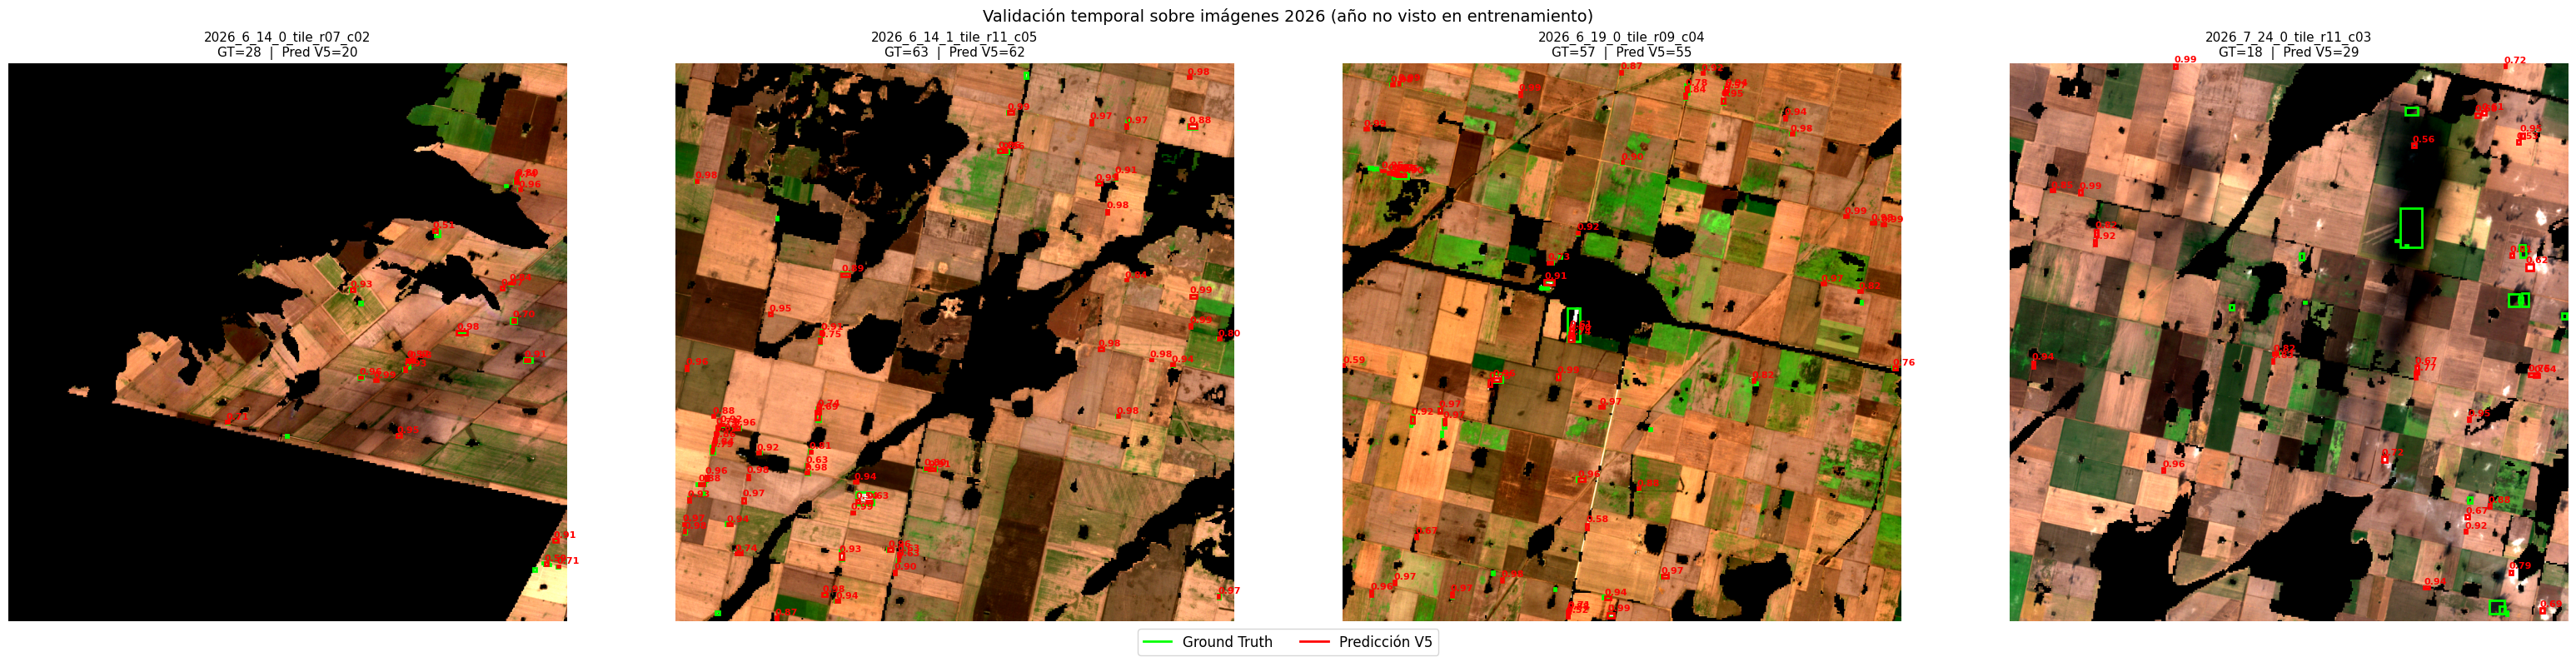

In [4]:
# ====================================================================
#  VALIDACIÓN TEMPORAL 2026 — Figura GT vs predicción (con dedup)
# ====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

VIZ_MODEL = 'V5'                      # modelo a mostrar
n = len(test_imgs_2026)
fig, axes = plt.subplots(1, n, figsize=(8 * n, 8))
if n == 1: axes = [axes]

for ax, img_name in zip(axes, test_imgs_2026):
    base = os.path.splitext(img_name)[0]
    img_path = os.path.join(TEST_2026_DIR, img_name)
    img_t = preprocess_image(img_path)               # (3,H,W) en [0,1]
    rgb = np.transpose(img_t.numpy(), (1, 2, 0))

    pos = rgb[rgb > 0]                               # realce de contraste (perc. 2-98)
    if pos.size > 0:
        lo, hi = np.percentile(pos, 2), np.percentile(pos, 98)
        rgb_disp = np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)
    else:
        rgb_disp = rgb
    ax.imshow(rgb_disp)

    gt = get_gt_boxes(img_name, TEST_2026_DIR)        # GT en verde
    for (x1, y1, x2, y2) in gt.numpy():
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                     fill=False, edgecolor='lime', linewidth=2))

    n_pred = 0
    if VIZ_MODEL in loaded:                           # predicción (deduplicada) en rojo
        pb, ps = predict_dedup(loaded[VIZ_MODEL], img_t)
        for (x1, y1, x2, y2), s in zip(pb, ps):
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                         fill=False, edgecolor='red', linewidth=2))
            ax.text(x1, y1 - 3, f"{s:.2f}", color='red', fontsize=8, weight='bold')
            n_pred += 1

    ax.set_title(f"{base}\nGT={len(gt)}  |  Pred {VIZ_MODEL}={n_pred}", fontsize=11)
    ax.axis('off')

fig.legend(handles=[Line2D([0], [0], color='lime', lw=2, label='Ground Truth'),
                    Line2D([0], [0], color='red',  lw=2, label=f'Predicción {VIZ_MODEL}')],
           loc='lower center', ncol=2, fontsize=12)
plt.suptitle("Validación temporal sobre imágenes 2026 (año no visto en entrenamiento)",
             fontsize=14)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
out_png = r"D:\Silos\Base_2026\validacion_2026.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"Figura guardada: {out_png}")
plt.show()

In [5]:
# === Significancia estadística 2026: Wilcoxon sobre FP + bootstrap pareado de AP ===
import numpy as np
from scipy.stats import wilcoxon

ag = ['V2','V4','V5']   # pares de interés; agregá 'V3' si querés
test_imgs = sorted(f for f in os.listdir(TEST_2026_DIR) if f.endswith('.tif'))

# cache de predicciones crudas por imagen y modelo (una sola inferencia)
cache = {}
for im in test_imgs:
    gt = get_gt_boxes(im, TEST_2026_DIR)
    img_t = preprocess_image(os.path.join(TEST_2026_DIR, im))
    d = {'gt': gt}
    for m in ag:
        with torch.no_grad(): pr = loaded[m]([img_t.to(device)])
        d[m] = (pr[0]['boxes'].cpu(), pr[0]['scores'].cpu())
    cache[im] = d

def fp_per_img(boxes, scores, gt):
    mk = scores >= THRESHOLD; b, s = boxes[mk], scores[mk]
    if len(b) > 0:
        k = tv_nms(b, s, NMS_IOU); b, s = b[k], s[k]
    # matched con la misma lógica greedy del notebook
    matched = set()
    if len(gt) > 0 and len(b) > 0:
        iou = box_iou(b, gt)
        for pi in np.argsort(-s.numpy()):
            best, bg = 0, -1
            for gj in range(len(gt)):
                if gj in matched: continue
                v = iou[pi, gj].item()
                if v > best: best, bg = v, gj
            if best >= IOU_THRESHOLD and bg >= 0: matched.add(bg)
    return len(b) - len(matched)

def dets_for_ap(boxes, scores, gt):
    # SIN umbral de confianza -> curva completa; devuelve lista (score, is_tp) y n_gt
    order = np.argsort(-scores.numpy())
    b, s = boxes[order], scores.numpy()[order]
    matched, out = set(), []
    iou = box_iou(b, gt) if (len(b) > 0 and len(gt) > 0) else None
    for pi in range(len(b)):
        is_tp = 0
        if iou is not None:
            best, bg = 0, -1
            for gj in range(len(gt)):
                if gj in matched: continue
                v = iou[pi, gj].item()
                if v > best: best, bg = v, gj
            if best >= IOU_THRESHOLD and bg >= 0: matched.add(bg); is_tp = 1
        out.append((float(s[pi]), is_tp))
    return out, len(gt)

per_img = {m: [] for m in ag}
for im in test_imgs:
    gt = cache[im]['gt']
    for m in ag:
        bx, sc = cache[im][m]
        fp = fp_per_img(bx, sc, gt)
        dets, ngt = dets_for_ap(bx, sc, gt)
        per_img[m].append({'fp': fp, 'dets': dets, 'n_gt': ngt})

# (1) Wilcoxon pareado sobre FP por imagen
print("== FP por imagen (Wilcoxon pareado) ==")
for a, b in [('V5','V4'), ('V5','V2'), ('V4','V2')]:
    diff = np.array([per_img[a][i]['fp'] - per_img[b][i]['fp'] for i in range(len(test_imgs))])
    p = wilcoxon(diff).pvalue if np.any(diff) else 1.0
    print(f"  {a} vs {b}: mediana dif = {np.median(diff):+.1f} | p = {p:.4f}")

# (2) Bootstrap pareado de AP (curva completa, 11 puntos)
def ap_from(imgs):
    dets = [d for im in imgs for d in im['dets']]; n_gt = sum(im['n_gt'] for im in imgs)
    if n_gt == 0 or not dets: return np.nan
    dets.sort(key=lambda x: -x[0]); tp = np.array([d[1] for d in dets])
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)
    prec, rec = ctp / np.maximum(ctp + cfp, 1), ctp / n_gt
    return sum((prec[rec >= t].max() if (rec >= t).any() else 0) for t in np.arange(0, 1.1, 0.1)) / 11

print("\n== AP curva completa (bootstrap pareado, 2000 remuestreos) ==")
rng, N, B = np.random.default_rng(0), len(test_imgs), 2000
for a, b in [('V5','V4'), ('V5','V2'), ('V4','V2')]:
    d = np.array([ap_from([per_img[a][i] for i in idx]) - ap_from([per_img[b][i] for i in idx])
                  for idx in (rng.integers(0, N, N) for _ in range(B))])
    lo, hi = np.percentile(d, [2.5, 97.5]); pb = 2 * min((d <= 0).mean(), (d >= 0).mean())
    print(f"  AP {a}-{b}: dif = {d.mean():+.3f} | IC95% [{lo:+.3f}, {hi:+.3f}] | p≈{pb:.3f}")

== FP por imagen (Wilcoxon pareado) ==
  V5 vs V4: mediana dif = +1.0 | p = 0.2215
  V5 vs V2: mediana dif = -2.0 | p = 0.0144
  V4 vs V2: mediana dif = -3.0 | p = 0.0156

== AP curva completa (bootstrap pareado, 2000 remuestreos) ==
  AP V5-V4: dif = +0.022 | IC95% [-0.020, +0.064] | p≈0.432
  AP V5-V2: dif = +0.041 | IC95% [-0.003, +0.073] | p≈0.090
  AP V4-V2: dif = +0.020 | IC95% [-0.008, +0.059] | p≈0.158
